# PantauPadi — Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
from google.colab import drive
import os

# Menghubungkan Google Colab dengan Drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/collab/pantaupadi"

# Berpindah ke folder tersebut
os.chdir(path)

# Cek apakah file-file yang kamu butuhkan sudah terlihat
print("File di folder ini:")
print(os.listdir())

Mounted at /content/drive
File di folder ini:
['final_iklim.csv', 'padi_bulanan_bps', 'luas_panen', 'full_dataset.csv', 'produktivias.csv', 'mergepadi.csv', 'pantaupadi_feature_table_final.csv', 'pantaupadi_modeling_table_final.csv', 'pantaupadi_latest_risk_2026_final.csv', 'pantaupadi_feature_table_final_clean.csv', 'pantaupadi_modeling_table_final_clean.csv', 'pantaupadi_latest_risk_2026_final_clean.csv', 'pantaupadi.ipynb']


## 1. Load Dataset

In [ ]:
feature_table = pd.read_csv('pantaupadi_feature_table_final_clean.csv')
feature_table['tanggal'] = pd.to_datetime(feature_table['tanggal'])

print("Shape:", feature_table.shape)
feature_table.head()

Shape: (3069, 37)


,wilayah,tahun,bulan,hujan_mm,HTH_hari,hujan_normal_mm,rasio_hujan_terhadap_normal,sifat_hujan,KAT_value,KAT_normal,rasio_KAT_terhadap_normal,produksi_padi_bulanan,luas_panen_bulanan,tanggal,hujan_score,HTH_score,KAT_score,climate_score,freq_penurunan,volatilitas,historical_score,final_score,risk_label,risk_label_bulan_depan,final_score_bulan_depan,hujan_mm_lag1,hujan_mm_roll3,rasio_hujan_terhadap_normal_lag1,rasio_hujan_terhadap_normal_roll3,HTH_hari_lag1,HTH_hari_roll3,rasio_KAT_terhadap_normal_lag1,rasio_KAT_terhadap_normal_roll3,climate_score_lag1,climate_score_roll3,faktor_dominan,rekomendasi_aksi
0,BANGKALAN,2018,1,451.514587,0,334.360256,1.350384,AN,392.434481,371.607650,1.056056,4739.48,785.0,2018-01-01,0,0,0,0,0.428571,0.070316,2,2,low,medium,4.0,NaN,451.514587,NaN,1.350384,NaN,0.0,NaN,1.056056,NaN,0.000000,Sensitivitas historis wilayah,Pantau rutin; belum membutuhkan intervensi pri...
1,BANGKALAN,2018,2,202.027545,2,250.459204,0.806629,BN,395.880555,378.690230,1.045244,46564.49,7716.0,2018-02-01,2,0,0,2,0.428571,0.070316,2,4,medium,medium,3.0,451.514587,326.771066,1.350384,1.078506,0.0,1.0,1.056056,1.050650,0.0,1.000000,"Curah hujan bawah normal, Sensitivitas histori...",Lakukan monitoring berkala dan validasi kondis...
2,BANGKALAN,2018,3,227.062383,1,243.218011,0.933576,N,395.380618,378.722207,1.043343,68927.85,11434.0,2018-03-01,0,0,1,1,0.428571,0.070316,2,3,medium,medium,5.0,202.027545,293.534838,0.806629,1.030196,2.0,1.0,1.045244,1.048214,2.0,1.000000,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
3,BANGKALAN,2018,4,97.913194,3,201.669351,0.485514,BN,376.930371,368.126476,1.021672,27021.81,4477.0,2018-04-01,2,0,1,3,0.428571,0.070316,2,5,medium,high,8.0,227.062383,175.667707,0.933576,0.741906,1.0,2.0,1.043343,1.036753,1.0,2.000000,"Curah hujan bawah normal, Sensitivitas histori...",Lakukan monitoring berkala dan validasi kondis...
4,BANGKALAN,2018,5,30.727801,17,115.417852,0.266231,BN,313.243207,342.708690,0.910004,12847.50,2218.0,2018-05-01,2,2,2,6,0.428571,0.070316,2,8,high,high,8.0,97.913194,118.567793,0.485514,0.561773,3.0,7.0,1.021672,0.991673,3.0,3.333333,"Curah hujan bawah normal, HTH panjang, Keterse...","Prioritaskan pemantauan lapangan, cek irigasi/..."


## 2. Quick Data Audit


In [ ]:
print("Rentang tahun:", feature_table['tahun'].min(), "-", feature_table['tahun'].max())
print("Jumlah wilayah:", feature_table['wilayah'].nunique())
print("Jumlah bulan unik:", feature_table[['tahun', 'bulan']].drop_duplicates().shape[0])

important_cols = [
    'wilayah', 'tahun', 'bulan', 'hujan_mm', 'HTH_hari',
    'rasio_hujan_terhadap_normal', 'sifat_hujan',
    'rasio_KAT_terhadap_normal', 'climate_score',
    'historical_score', 'final_score', 'risk_label',
    'faktor_dominan', 'rekomendasi_aksi'
]

feature_table[important_cols].isna().sum()

Rentang tahun: 2018 - 2026
Jumlah wilayah: 31
Jumlah bulan unik: 99


,0
wilayah,0
tahun,0
bulan,0
hujan_mm,0
HTH_hari,0
rasio_hujan_terhadap_normal,0
sifat_hujan,0
rasio_KAT_terhadap_normal,0
climate_score,0
historical_score,0


## 3. Distribusi Label Risiko

Pertanyaan:


In [ ]:
risk_order = ['low', 'medium', 'high']

risk_dist = (
    feature_table['risk_label']
    .value_counts()
    .reindex(risk_order)
    .reset_index()
)

risk_dist.columns = ['risk_label', 'jumlah']
risk_dist['persentase'] = (risk_dist['jumlah'] / risk_dist['jumlah'].sum() * 100).round(2)

risk_dist

,risk_label,jumlah,persentase
0,low,830,27.04
1,medium,1371,44.67
2,high,868,28.28


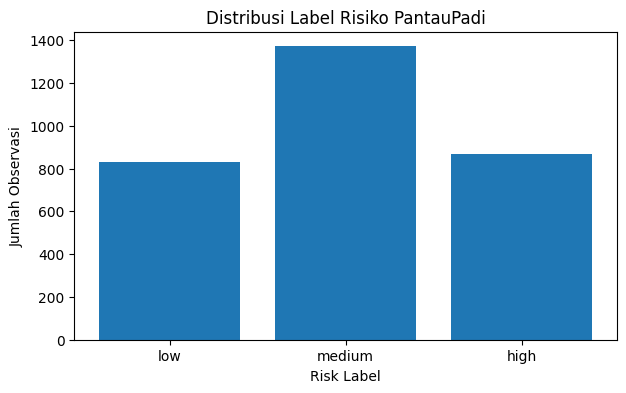

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(risk_dist['risk_label'], risk_dist['jumlah'])
plt.title('Distribusi Label Risiko PantauPadi')
plt.xlabel('Risk Label')
plt.ylabel('Jumlah Observasi')
plt.show()

## 4. Risiko per Tahun

In [ ]:
risk_by_year = pd.crosstab(
    feature_table['tahun'],
    feature_table['risk_label'],
    normalize='index'
).reindex(columns=risk_order)

risk_by_year_percent = (risk_by_year * 100).round(2)
risk_by_year_percent

risk_label,low,medium,high
tahun,,,
2018,13.17,35.48,51.34
2019,12.63,28.49,58.87
2020,28.23,59.68,12.10
2021,40.05,44.35,15.59
2022,45.70,53.23,1.08
2023,10.48,34.68,54.84
2024,14.25,50.00,35.75
2025,45.43,50.81,3.76
2026,52.69,47.31,0.00


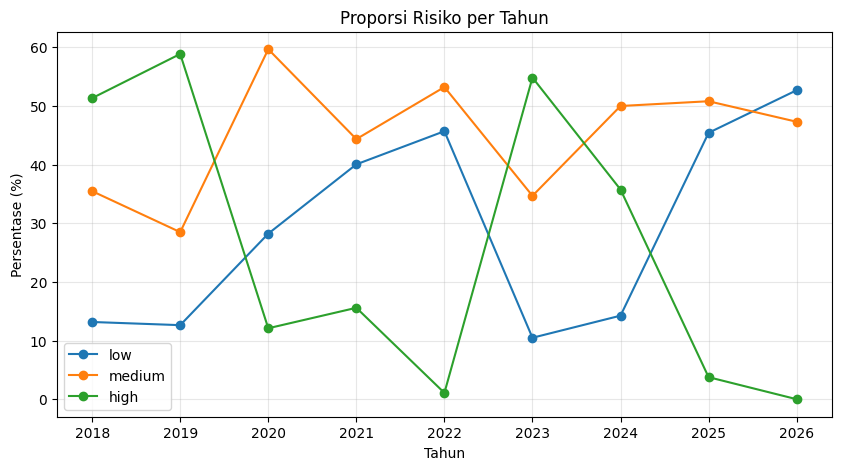

In [ ]:
plt.figure(figsize=(10, 5))
for label in risk_order:
    plt.plot(risk_by_year_percent.index, risk_by_year_percent[label], marker='o', label=label)

plt.title('Proporsi Risiko per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Persentase (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Bulan Paling Rawan High Risk

In [ ]:
monthly_high = (
    feature_table[feature_table['risk_label'] == 'high']
    .groupby('bulan')
    .size()
    .reset_index(name='jumlah_high_risk')
)

monthly_total = (
    feature_table.groupby('bulan')
    .size()
    .reset_index(name='total_observasi')
)

monthly_risk = monthly_high.merge(monthly_total, on='bulan', how='right').fillna(0)
monthly_risk['jumlah_high_risk'] = monthly_risk['jumlah_high_risk'].astype(int)
monthly_risk['persen_high_risk'] = (
    monthly_risk['jumlah_high_risk'] / monthly_risk['total_observasi'] * 100
).round(2)

monthly_risk

,bulan,jumlah_high_risk,total_observasi,persen_high_risk
0,1,4,279,1.43
1,2,4,279,1.43
2,3,25,279,8.96
3,4,54,248,21.77
4,5,125,248,50.40
5,6,125,248,50.40
6,7,94,248,37.90
7,8,99,248,39.92
8,9,119,248,47.98
9,10,118,248,47.58


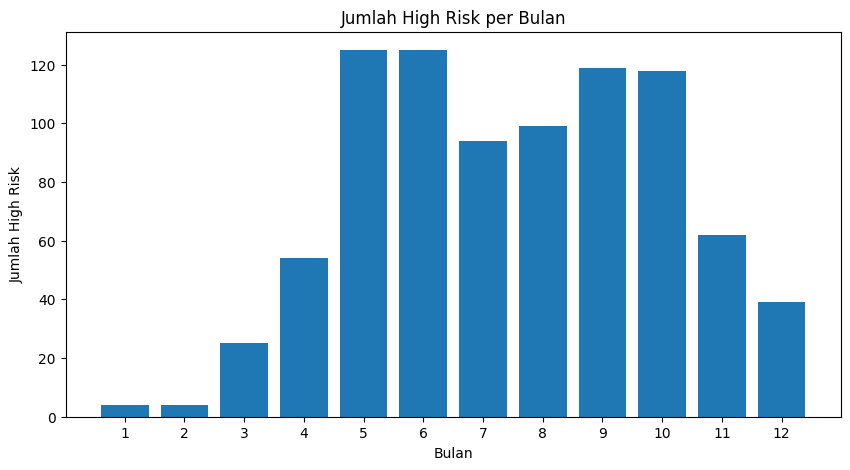

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_risk['bulan'], monthly_risk['jumlah_high_risk'])
plt.title('Jumlah High Risk per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah High Risk')
plt.xticks(range(1, 13))
plt.show()

## 6. Wilayah yang Paling Sering High Risk

In [ ]:
area_total = feature_table.groupby('wilayah').size().reset_index(name='total_observasi')

area_high = (
    feature_table[feature_table['risk_label'] == 'high']
    .groupby('wilayah')
    .size()
    .reset_index(name='jumlah_high_risk')
)

area_risk = area_total.merge(area_high, on='wilayah', how='left').fillna(0)
area_risk['jumlah_high_risk'] = area_risk['jumlah_high_risk'].astype(int)
area_risk['persen_high_risk'] = (
    area_risk['jumlah_high_risk'] / area_risk['total_observasi'] * 100
).round(2)

top_high_area = area_risk.sort_values(
    ['jumlah_high_risk', 'persen_high_risk'],
    ascending=False
).head(10)

top_high_area

,wilayah,total_observasi,jumlah_high_risk,persen_high_risk
3,BLITAR,99,39,39.39
15,MOJOKERTO,99,37,37.37
19,PAMEKASAN,99,37,37.37
22,PROBOLINGGO,99,36,36.36
23,SAMPANG,99,36,36.36
10,LAMONGAN,99,35,35.35
20,PASURUAN,99,35,35.35
26,SUMENEP,99,35,35.35
2,BATU,99,34,34.34
27,SURABAYA,99,34,34.34


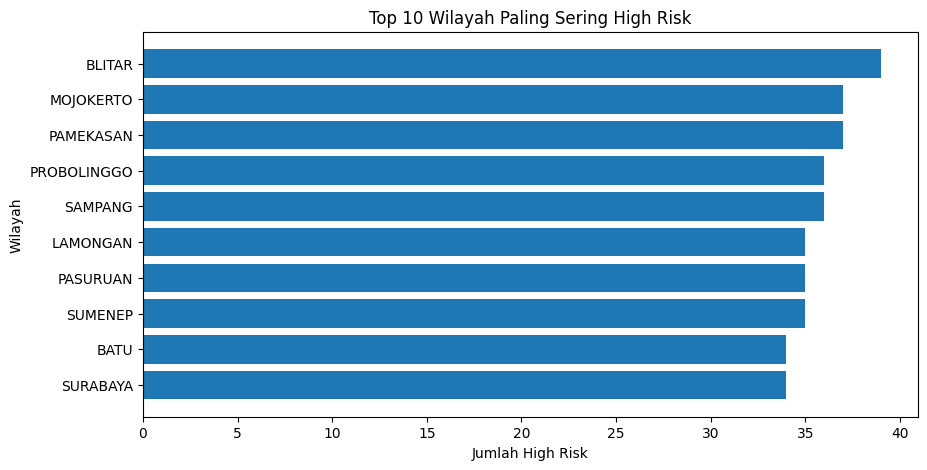

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(top_high_area['wilayah'][::-1], top_high_area['jumlah_high_risk'][::-1])
plt.title('Top 10 Wilayah Paling Sering High Risk')
plt.xlabel('Jumlah High Risk')
plt.ylabel('Wilayah')
plt.show()

## 7. Faktor Dominan Risiko

Pertanyaan:
> Faktor apa yang paling sering menjadi alasan wilayah masuk risiko?

In [ ]:
factor_counts = (
    feature_table['faktor_dominan']
    .value_counts()
    .reset_index()
)

factor_counts.columns = ['faktor_dominan', 'jumlah']
factor_counts.head(15)

,faktor_dominan,jumlah
0,Sensitivitas historis wilayah,897
1,"Curah hujan bawah normal, HTH panjang, Keterse...",294
2,"HTH panjang, Sensitivitas historis wilayah",256
3,"Ketersediaan air rendah, Sensitivitas historis...",252
4,Ketersediaan air rendah,206
5,HTH panjang,165
6,"Curah hujan bawah normal, HTH panjang, Keterse...",153
7,"Curah hujan bawah normal, Sensitivitas histori...",129
8,"Curah hujan bawah normal, Ketersediaan air ren...",119
9,"Curah hujan bawah normal, Ketersediaan air rendah",106


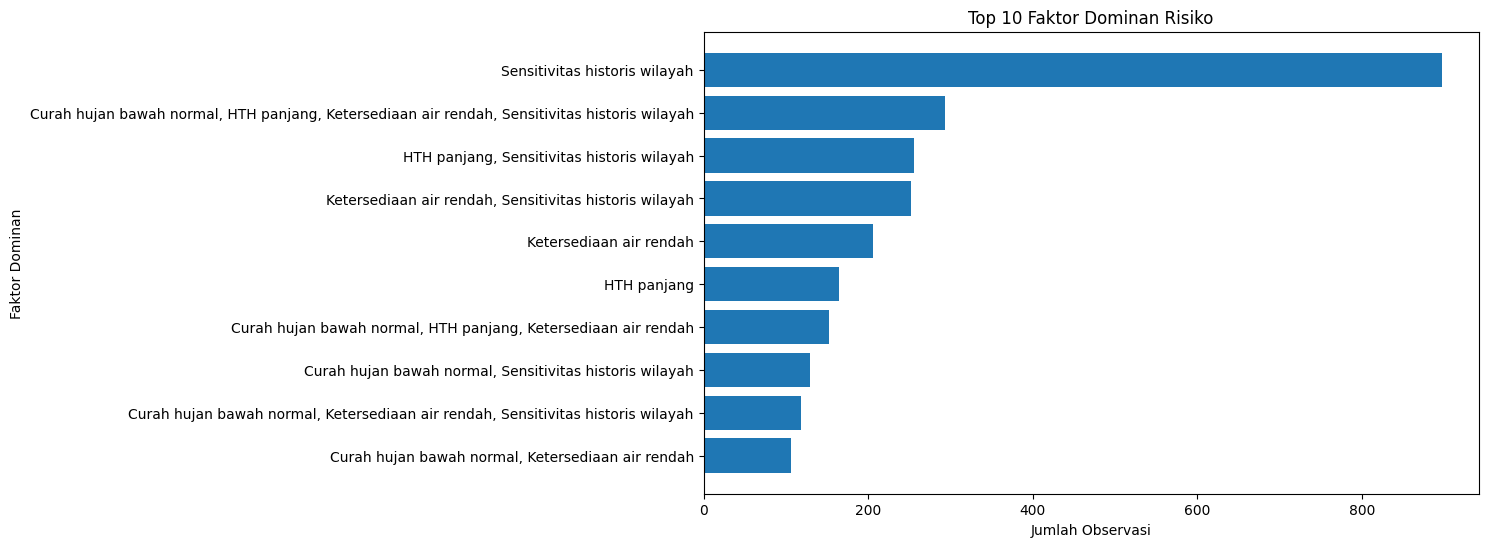

In [ ]:
top_factors = factor_counts.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_factors['faktor_dominan'][::-1], top_factors['jumlah'][::-1])
plt.title('Top 10 Faktor Dominan Risiko')
plt.xlabel('Jumlah Observasi')
plt.ylabel('Faktor Dominan')
plt.show()

## 8. Tren Indikator Iklim dan Skor

In [ ]:
trend_year = (
    feature_table.groupby('tahun')
    .agg(
        avg_climate_score=('climate_score', 'mean'),
        avg_final_score=('final_score', 'mean'),
        avg_HTH=('HTH_hari', 'mean'),
        avg_rasio_hujan=('rasio_hujan_terhadap_normal', 'mean'),
        avg_rasio_KAT=('rasio_KAT_terhadap_normal', 'mean')
    )
    .round(3)
    .reset_index()
)

trend_year

,tahun,avg_climate_score,avg_final_score,avg_HTH,avg_rasio_hujan,avg_rasio_KAT
0,2018,3.844,5.263,11.462,0.762,0.855
1,2019,4.169,5.589,12.320,0.630,0.821
2,2020,1.944,3.363,8.860,1.185,1.051
3,2021,1.917,3.336,8.589,1.382,1.081
4,2022,1.134,2.554,6.457,1.761,1.199
5,2023,3.976,5.395,13.720,0.775,0.897
6,2024,3.234,4.653,11.040,0.959,0.894
7,2025,1.272,2.691,7.903,1.766,1.113
8,2026,0.785,2.204,2.043,1.177,1.033


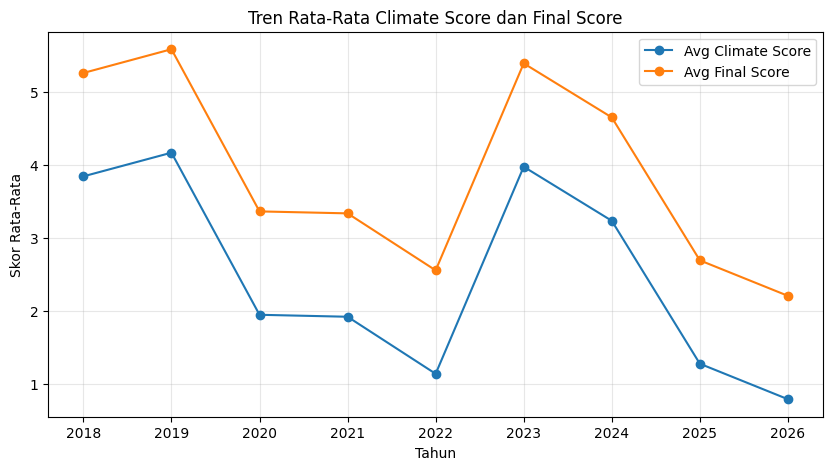

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(trend_year['tahun'], trend_year['avg_climate_score'], marker='o', label='Avg Climate Score')
plt.plot(trend_year['tahun'], trend_year['avg_final_score'], marker='o', label='Avg Final Score')
plt.title('Tren Rata-Rata Climate Score dan Final Score')
plt.xlabel('Tahun')
plt.ylabel('Skor Rata-Rata')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Hubungan Antara Indikator dengan Final Score

In [ ]:
corr_cols = [
    'hujan_mm',
    'rasio_hujan_terhadap_normal',
    'HTH_hari',
    'rasio_KAT_terhadap_normal',
    'hujan_score',
    'HTH_score',
    'KAT_score',
    'climate_score',
    'historical_score',
    'final_score'
]

corr_matrix = feature_table[corr_cols].corr(numeric_only=True).round(3)
corr_matrix

,hujan_mm,rasio_hujan_terhadap_normal,HTH_hari,rasio_KAT_terhadap_normal,hujan_score,HTH_score,KAT_score,climate_score,historical_score,final_score
hujan_mm,1.000,0.319,-0.704,0.320,-0.535,-0.824,-0.314,-0.725,-0.042,-0.687
rasio_hujan_terhadap_normal,0.319,1.000,-0.228,0.623,-0.647,-0.212,-0.571,-0.626,0.006,-0.578
HTH_hari,-0.704,-0.228,1.000,-0.283,0.416,0.812,0.269,0.645,0.069,0.623
rasio_KAT_terhadap_normal,0.320,0.623,-0.283,1.000,-0.486,-0.241,-0.836,-0.670,0.010,-0.617
hujan_score,-0.535,-0.647,0.416,-0.486,1.000,0.450,0.482,0.856,-0.000,0.793
HTH_score,-0.824,-0.212,0.812,-0.241,0.450,1.000,0.219,0.720,0.049,0.685
KAT_score,-0.314,-0.571,0.269,-0.836,0.482,0.219,1.000,0.726,-0.022,0.664
climate_score,-0.725,-0.626,0.645,-0.670,0.856,0.720,0.726,1.000,0.011,0.931
historical_score,-0.042,0.006,0.069,0.010,-0.000,0.049,-0.022,0.011,1.000,0.376
final_score,-0.687,-0.578,0.623,-0.617,0.793,0.685,0.664,0.931,0.376,1.000


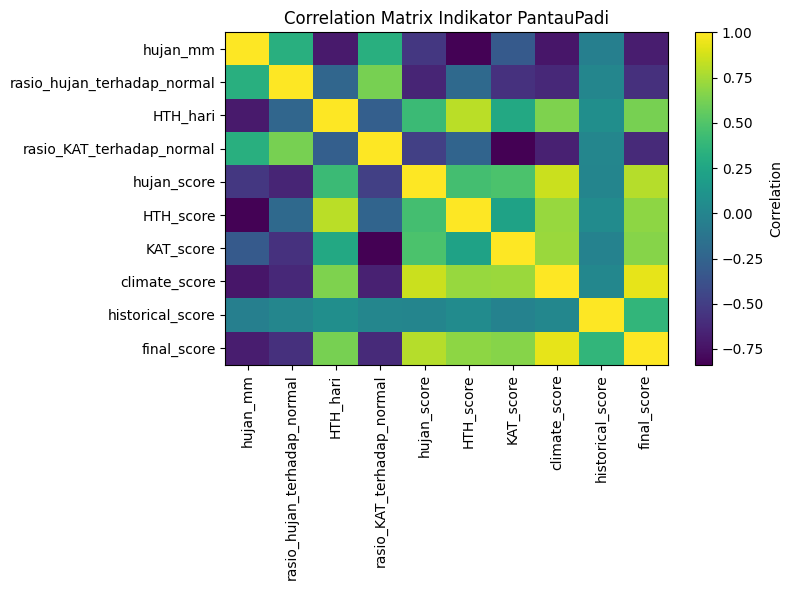

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Matrix Indikator PantauPadi')
plt.tight_layout()
plt.show()

## 10. Analisis Data Terbaru 2026

In [ ]:
latest_2026 = feature_table[feature_table['tahun'] == 2026].copy()

latest_dist = (
    latest_2026['risk_label']
    .value_counts()
    .reindex(risk_order)
    .fillna(0)
    .astype(int)
    .reset_index()
)

latest_dist.columns = ['risk_label', 'jumlah']
latest_dist['persentase'] = (latest_dist['jumlah'] / latest_dist['jumlah'].sum() * 100).round(2)

latest_dist

,risk_label,jumlah,persentase
0,low,49,52.69
1,medium,44,47.31
2,high,0,0.00


In [ ]:
latest_by_month = pd.crosstab(
    latest_2026['bulan'],
    latest_2026['risk_label']
).reindex(columns=risk_order).fillna(0).astype(int)

latest_by_month

risk_label,low,medium,high
bulan,,,
1,20,11,0
2,16,15,0
3,13,18,0


In [ ]:
latest_priority = latest_2026.sort_values(
    ['final_score', 'climate_score', 'historical_score'],
    ascending=False
)[[
    'wilayah', 'tahun', 'bulan', 'risk_label',
    'final_score', 'climate_score', 'historical_score',
    'sifat_hujan', 'HTH_hari', 'rasio_KAT_terhadap_normal',
    'faktor_dominan', 'rekomendasi_aksi'
]]

latest_priority.head(20)

,wilayah,tahun,bulan,risk_label,final_score,climate_score,historical_score,sifat_hujan,HTH_hari,rasio_KAT_terhadap_normal,faktor_dominan,rekomendasi_aksi
197,BANYUWANGI,2026,3,medium,4,2,2,N,4,1.030853,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
1979,PAMEKASAN,2026,3,medium,4,2,2,N,5,0.965501,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
3068,TULUNGAGUNG,2026,3,medium,4,2,2,N,4,1.001448,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
96,BANGKALAN,2026,1,medium,3,1,2,N,2,1.015650,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
97,BANGKALAN,2026,2,medium,3,1,2,AN,2,0.986413,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
98,BANGKALAN,2026,3,medium,3,1,2,N,3,0.967354,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
294,BATU,2026,1,medium,3,1,2,N,2,1.018312,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
295,BATU,2026,2,medium,3,1,2,AN,2,1.005810,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
296,BATU,2026,3,medium,3,1,2,AN,3,0.965766,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...
393,BLITAR,2026,1,medium,3,1,2,AN,2,1.041464,Sensitivitas historis wilayah,Lakukan monitoring berkala dan validasi kondis...


## 11. Ringkasan Insight Otomatis

In [ ]:
total_data = len(feature_table)
total_wilayah = feature_table['wilayah'].nunique()
year_min, year_max = feature_table['tahun'].min(), feature_table['tahun'].max()

top_year_high = risk_by_year_percent['high'].idxmax()
top_year_high_pct = risk_by_year_percent.loc[top_year_high, 'high']

top_month_high = monthly_risk.sort_values('jumlah_high_risk', ascending=False).iloc[0]
top_area_high = top_high_area.iloc[0]

print(f"Dataset berisi {total_data} observasi dari {total_wilayah} wilayah pada periode {year_min}-{year_max}.")
print(f"Label risiko terbanyak: {risk_dist.sort_values('jumlah', ascending=False).iloc[0]['risk_label']}.")
print(f"Tahun dengan proporsi high risk tertinggi: {top_year_high} ({top_year_high_pct}%).")
print(f"Bulan dengan jumlah high risk tertinggi: bulan {int(top_month_high['bulan'])} ({int(top_month_high['jumlah_high_risk'])} observasi).")
print(f"Wilayah paling sering high risk: {top_area_high['wilayah']} ({int(top_area_high['jumlah_high_risk'])} observasi high risk).")
print(f"Pada 2026, distribusi risiko adalah:")
print(latest_dist)

Dataset berisi 3069 observasi dari 31 wilayah pada periode 2018-2026.
Label risiko terbanyak: medium.
Tahun dengan proporsi high risk tertinggi: 2019 (58.87%).
Bulan dengan jumlah high risk tertinggi: bulan 6 (125 observasi).
Wilayah paling sering high risk: BLITAR (39 observasi high risk).
Pada 2026, distribusi risiko adalah:
  risk_label  jumlah  persentase
0        low      49       52.69
1     medium      44       47.31
2       high       0        0.00


## 12. Export Tabel Ringkasan EDA

In [ ]:
risk_dist.to_csv('eda_distribusi_risiko.csv', index=False)
risk_by_year_percent.to_csv('eda_risiko_per_tahun.csv')
monthly_risk.to_csv('eda_bulan_rawan.csv', index=False)
top_high_area.to_csv('eda_top_wilayah_high_risk.csv', index=False)
factor_counts.to_csv('eda_faktor_dominan.csv', index=False)
trend_year.to_csv('eda_tren_tahunan.csv', index=False)
latest_priority.to_csv('eda_prioritas_2026.csv', index=False)

print("File EDA berhasil diexport.")

File EDA berhasil diexport.


Berdasarkan hasil EDA, mayoritas observasi PantauPadi berada pada kategori medium risk sebesar 44,67%, disusul high risk sebesar 28,28% dan low risk sebesar 27,04%. Pola ini menunjukkan bahwa sistem risk scoring tidak hanya menghasilkan kondisi aman, tetapi mampu mengidentifikasi wilayah yang membutuhkan pemantauan lebih lanjut.

Secara tahunan, 2019 menjadi tahun dengan proporsi high risk tertinggi, yaitu 58,87%. Tahun 2023 juga menunjukkan peningkatan risiko yang cukup tinggi. Hal ini terlihat sejalan dengan peningkatan rata-rata climate_score pada tahun-tahun tersebut.

Secara bulanan, high risk paling banyak muncul pada bulan Mei, Juni, September, dan Oktober. Bulan Juni menjadi salah satu bulan dengan jumlah high risk tertinggi, yaitu 125 observasi. Temuan ini dapat membantu Dinas Pertanian menentukan periode pemantauan yang lebih intensif.

Dari sisi wilayah, Blitar menjadi wilayah yang paling sering masuk kategori high risk, dengan 39 observasi high risk. Wilayah lain yang juga sering muncul dalam kategori high risk adalah Mojokerto, Pamekasan, Probolinggo, dan Sampang. Wilayah-wilayah ini dapat menjadi prioritas untuk pemantauan lapangan dan validasi kondisi pertanian.

Faktor dominan risiko yang paling sering muncul adalah sensitivitas historis wilayah. Artinya, risiko tidak hanya dipengaruhi oleh kondisi iklim bulan tertentu, tetapi juga oleh karakter historis wilayah seperti frekuensi penurunan dan volatilitas produksi/luas panen.

Pada data terbaru 2026, belum terdapat wilayah high risk. Namun terdapat 44 observasi medium risk, sehingga sistem tetap berguna untuk memberikan peringatan dini sebelum risiko meningkat menjadi tinggi.